# Обучение с подкреплением: задача Taxi-v3

В этом ноутбуке реализуем простой алгоритм Q-обучения (Q-learning) для задачи `Taxi-v3` из библиотеки OpenAI Gym (или Gymnasium).

Структура ноутбука:
- подготовка окружения и установка зависимостей;
- создание среды `Taxi-v3`;
- обучение агента с помощью Q-обучения;
- оценка обученной политики и сохранение Q-таблицы.

In [ ]:
# Установка зависимостей (запустите эту ячейку один раз)
# gym 0.26 несовместим с NumPy 2.x (нет np.bool8), поэтому ставим numpy<2
import sys

!{sys.executable} -m pip install -q "numpy>=1.20,<2" gym==0.26.2 "gym[toy_text]==0.26.2"

In [2]:
import gym
import numpy as np

# Создание среды Taxi-v3 (render_mode="ansi" — текстовая визуализация без pygame)
env = gym.make("Taxi-v3", render_mode="ansi")

n_states = env.observation_space.n
n_actions = env.action_space.n

print("Состояний:", n_states, "Действий:", n_actions)

Состояний: 500 Действий: 6


In [3]:
# Гиперпараметры Q-обучения
alpha = 0.1       # скорость обучения
gamma = 0.99      # коэффициент дисконтирования
epsilon = 1.0     # начальная вероятность случайного действия
epsilon_min = 0.01
epsilon_decay = 0.999
n_episodes = 20000
max_steps = 100

# Q-таблица (состояние x действие)
q_table = np.zeros((n_states, n_actions))

def choose_action(state, epsilon):
    """epsilon-greedy выбор действия."""
    if np.random.rand() < epsilon:
        return env.action_space.sample()
    return int(np.argmax(q_table[state]))

rewards_per_thousand = []
rolling_reward = 0

for episode in range(1, n_episodes + 1):
    state, _ = env.reset()
    done = False
    episode_reward = 0

    for step in range(max_steps):
        action = choose_action(state, epsilon)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # Обновление Q-значения по формуле Беллмана
        best_next = np.max(q_table[next_state])
        q_table[state, action] = q_table[state, action] + alpha * (
            reward + gamma * best_next - q_table[state, action]
        )

        state = next_state
        episode_reward += reward

        if done:
            break

    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    rolling_reward += episode_reward

    if episode % 1000 == 0:
        avg = rolling_reward / 1000
        rewards_per_thousand.append(avg)
        print(f"Эпизоды {episode-999}-{episode}, средняя награда: {avg:.2f}, epsilon: {epsilon:.3f}")
        rolling_reward = 0

print("Обучение завершено.")

c:\Users\User\.conda\envs\NPC\lib\site-packages\gym\utils\passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


Эпизоды 1-1000, средняя награда: -248.71, epsilon: 0.368
Эпизоды 1001-2000, средняя награда: -37.48, epsilon: 0.135
Эпизоды 2001-3000, средняя награда: 2.60, epsilon: 0.050
Эпизоды 3001-4000, средняя награда: 6.26, epsilon: 0.018
Эпизоды 4001-5000, средняя награда: 7.32, epsilon: 0.010
Эпизоды 5001-6000, средняя награда: 7.51, epsilon: 0.010
Эпизоды 6001-7000, средняя награда: 7.58, epsilon: 0.010
Эпизоды 7001-8000, средняя награда: 7.35, epsilon: 0.010
Эпизоды 8001-9000, средняя награда: 7.54, epsilon: 0.010
Эпизоды 9001-10000, средняя награда: 7.16, epsilon: 0.010
Эпизоды 10001-11000, средняя награда: 7.25, epsilon: 0.010
Эпизоды 11001-12000, средняя награда: 7.29, epsilon: 0.010
Эпизоды 12001-13000, средняя награда: 7.49, epsilon: 0.010
Эпизоды 13001-14000, средняя награда: 7.37, epsilon: 0.010
Эпизоды 14001-15000, средняя награда: 7.45, epsilon: 0.010
Эпизоды 15001-16000, средняя награда: 7.35, epsilon: 0.010
Эпизоды 16001-17000, средняя награда: 7.34, epsilon: 0.010
Эпизоды 17001-

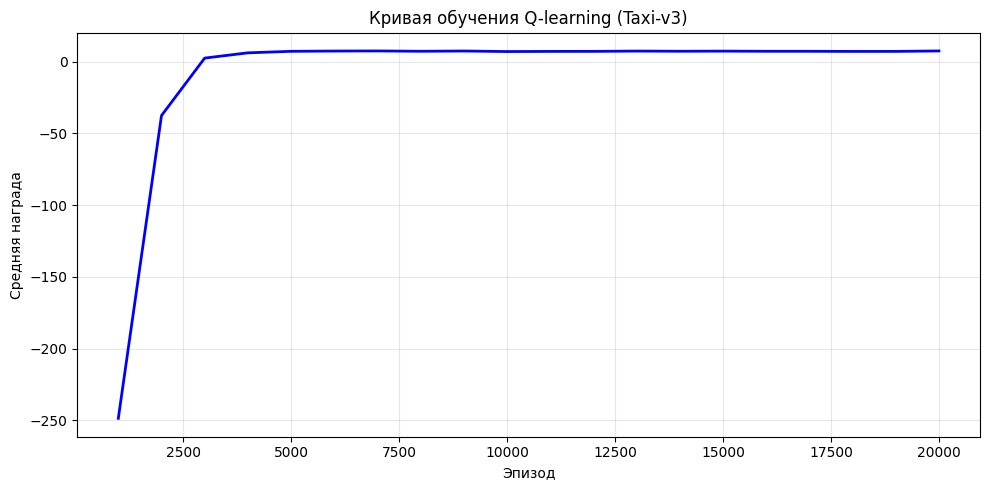

In [4]:
# График обучения: средняя награда каждые 1000 эпизодов
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(range(1000, n_episodes + 1, 1000), rewards_per_thousand, "b-", linewidth=2)
plt.xlabel("Эпизод")
plt.ylabel("Средняя награда")
plt.title("Кривая обучения Q-learning (Taxi-v3)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
# Оценка обученной политики (анимация движения такси)
from IPython.display import clear_output
import time

n_eval_episodes = 3
max_steps = 100

for episode in range(1, n_eval_episodes + 1):
    state, _ = env.reset()
    done = False
    total_reward = 0

    for step in range(max_steps):
        # Действуем жадно по Q-таблице
        action = int(np.argmax(q_table[state]))
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        total_reward += reward
        state = next_state

        # Анимация: очищаем вывод и показываем текущий кадр
        clear_output(wait=True)
        print(f"Эпизод {episode}/{n_eval_episodes}, шаг {step + 1}")
        print(env.render())
        time.sleep(0.2)

        if done:
            break

    print(f"Награда за эпизод {episode}: {total_reward}")
    time.sleep(1)  # пауза между эпизодами

env.close()
print("\nОценка завершена.")

Эпизод 3/3, шаг 6
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (Dropoff)

Награда за эпизод 3: 15

Оценка завершена.


In [6]:
# Сохранение обученной Q-таблицы
np.save("taxi_q_table.npy", q_table)
print("Q-таблица сохранена в файл taxi_q_table.npy")

Q-таблица сохранена в файл taxi_q_table.npy


---
## Альтернативный подход: Deep Q-Network (DQN)

Ниже реализован **DQN** — нейросетевой аналог Q-learning.  
Вместо Q-таблицы используется полносвязная нейронная сеть (PyTorch), которая принимает one-hot вектор состояния и предсказывает Q-значения для каждого действия.

**Ключевые отличия от табличного Q-learning:**
- Состояние кодируется как one-hot вектор (размерность 500)
- Q-функция аппроксимируется нейросетью с 2 скрытыми слоями
- Используется Experience Replay (буфер воспроизведения опыта)
- Используется Target Network (целевая сеть для стабильности обучения)

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

# ── Среда ──
env_dqn = gym.make("Taxi-v3", render_mode="ansi")
N_STATES  = env_dqn.observation_space.n   # 500
N_ACTIONS = env_dqn.action_space.n        # 6

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Устройство: {device}")


# ── Нейросеть Q-функции ──
class DQN(nn.Module):
    """Полносвязная сеть: one-hot(500) → 128 → 64 → 6 (Q-значения)."""
    def __init__(self, n_states, n_actions):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_states, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, n_actions),
        )

    def forward(self, x):
        return self.net(x)


def state_to_tensor(state, n_states=N_STATES):
    """Преобразует целочисленное состояние в one-hot тензор."""
    one_hot = torch.zeros(n_states, device=device)
    one_hot[state] = 1.0
    return one_hot


# ── Буфер воспроизведения опыта ──
class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            torch.stack([state_to_tensor(s) for s in states]),
            torch.tensor(actions, device=device, dtype=torch.long),
            torch.tensor(rewards, device=device, dtype=torch.float32),
            torch.stack([state_to_tensor(s) for s in next_states]),
            torch.tensor(dones, device=device, dtype=torch.float32),
        )

    def __len__(self):
        return len(self.buffer)


# ── Гиперпараметры DQN ──
LR             = 1e-3
GAMMA          = 0.99
EPSILON_START  = 1.0
EPSILON_MIN    = 0.01
EPSILON_DECAY  = 0.999
BATCH_SIZE     = 64
BUFFER_SIZE    = 10000
TARGET_UPDATE  = 10      # каждые N эпизодов копируем веса в target-сеть
N_EPISODES_DQN = 5000
MAX_STEPS      = 100

# ── Инициализация ──
policy_net = DQN(N_STATES, N_ACTIONS).to(device)
target_net = DQN(N_STATES, N_ACTIONS).to(device)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=LR)
loss_fn   = nn.MSELoss()
buffer    = ReplayBuffer(BUFFER_SIZE)

eps = EPSILON_START
dqn_rewards = []
dqn_rolling = 0
dqn_rewards_per_100 = []

# ── Цикл обучения DQN ──
for episode in range(1, N_EPISODES_DQN + 1):
    state, _ = env_dqn.reset()
    episode_reward = 0

    for step in range(MAX_STEPS):
        # epsilon-greedy
        if random.random() < eps:
            action = env_dqn.action_space.sample()
        else:
            with torch.no_grad():
                q_vals = policy_net(state_to_tensor(state).unsqueeze(0))
                action = q_vals.argmax(dim=1).item()

        next_state, reward, terminated, truncated, _ = env_dqn.step(action)
        done = terminated or truncated
        buffer.push(state, action, reward, next_state, done)

        state = next_state
        episode_reward += reward

        # Обучение по мини-батчу
        if len(buffer) >= BATCH_SIZE:
            s, a, r, ns, d = buffer.sample(BATCH_SIZE)

            # Q(s, a) из policy-сети
            q_values = policy_net(s).gather(1, a.unsqueeze(1)).squeeze(1)

            # target: r + gamma * max_a' Q_target(s', a')
            with torch.no_grad():
                next_q = target_net(ns).max(dim=1)[0]
                target = r + GAMMA * next_q * (1 - d)

            loss = loss_fn(q_values, target)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        if done:
            break

    eps = max(EPSILON_MIN, eps * EPSILON_DECAY)
    dqn_rolling += episode_reward

    # Обновление target-сети
    if episode % TARGET_UPDATE == 0:
        target_net.load_state_dict(policy_net.state_dict())

    # Логирование
    if episode % 100 == 0:
        avg = dqn_rolling / 100
        dqn_rewards_per_100.append(avg)
        print(f"[DQN] Эпизоды {episode-99}-{episode}, средняя награда: {avg:.2f}, eps: {eps:.3f}")
        dqn_rolling = 0

print("DQN обучение завершено.")

Устройство: cpu


c:\Users\User\.conda\envs\NPC\lib\site-packages\gym\utils\passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


[DQN] Эпизоды 1-100, средняя награда: -377.04, eps: 0.905
[DQN] Эпизоды 101-200, средняя награда: -334.68, eps: 0.819
[DQN] Эпизоды 201-300, средняя награда: -287.35, eps: 0.741
[DQN] Эпизоды 301-400, средняя награда: -238.50, eps: 0.670
[DQN] Эпизоды 401-500, средняя награда: -161.57, eps: 0.606
[DQN] Эпизоды 501-600, средняя награда: -81.26, eps: 0.549
[DQN] Эпизоды 601-700, средняя награда: -54.59, eps: 0.496
[DQN] Эпизоды 701-800, средняя награда: -33.29, eps: 0.449
[DQN] Эпизоды 801-900, средняя награда: -30.62, eps: 0.406
[DQN] Эпизоды 901-1000, средняя награда: -23.77, eps: 0.368
[DQN] Эпизоды 1001-1100, средняя награда: -21.70, eps: 0.333
[DQN] Эпизоды 1101-1200, средняя награда: -13.47, eps: 0.301
[DQN] Эпизоды 1201-1300, средняя награда: -11.06, eps: 0.272
[DQN] Эпизоды 1301-1400, средняя награда: -9.24, eps: 0.246
[DQN] Эпизоды 1401-1500, средняя награда: -7.49, eps: 0.223
[DQN] Эпизоды 1501-1600, средняя награда: -3.13, eps: 0.202
[DQN] Эпизоды 1601-1700, средняя награда: -

KeyboardInterrupt: 

In [ ]:
# График обучения DQN
plt.figure(figsize=(10, 5))
plt.plot(range(100, N_EPISODES_DQN + 1, 100), dqn_rewards_per_100, "r-", linewidth=2, label="DQN")
plt.xlabel("Эпизод")
plt.ylabel("Средняя награда (за 100 эп.)")
plt.title("Кривая обучения DQN (Taxi-v3)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Оценка DQN (анимация)
n_eval = 3

for episode in range(1, n_eval + 1):
    state, _ = env_dqn.reset()
    total_reward = 0

    for step in range(MAX_STEPS):
        with torch.no_grad():
            q_vals = policy_net(state_to_tensor(state).unsqueeze(0))
            action = q_vals.argmax(dim=1).item()

        next_state, reward, terminated, truncated, _ = env_dqn.step(action)
        done = terminated or truncated
        total_reward += reward
        state = next_state

        clear_output(wait=True)
        print(f"[DQN] Эпизод {episode}/{n_eval}, шаг {step + 1}")
        print(env_dqn.render())
        time.sleep(0.2)

        if done:
            break

    print(f"Награда за эпизод {episode}: {total_reward}")
    time.sleep(1)

env_dqn.close()
print("\nОценка DQN завершена.")